In [ ]:
### Remote Sensing Forest Change: Detecting Forest Conversion and its Biogeophysical Climate Effects and Ecological Effects in Bavaria
### Code for the Master's Thesis by Julia Jamula

## NDVI Seasonal Differences Distributions

In [ ]:
import ee
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np

ee.Authenticate()
PROJECT_NAME='xxx'
ee.Initialize(project=PROJECT_NAME)

ASSET="xxx" # insert path
bayern = ee.FeatureCollection(ASSET)

In [ ]:

lc = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover")

# NDVI mask
def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask)

NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").map(maskNDVI).select('NDVI')
modis_proj = NDVI.first().projection()

In [13]:
# 2018 seasonal NDVI differences - Export


year=2018

# Season mean
def season_mean(year, months):
    imgs = []
    for m in months:
        start = ee.Date.fromYMD(year, m, 1)
        end   = start.advance(1, "month")
        coll  = NDVI.filterDate(start, end)
        imgs.append(coll.mean()) 
    return ee.ImageCollection(imgs).mean()

winter = season_mean(year, [1,2,3])
summer = season_mean(year, [5,6,7])


# Difference
diff = summer.subtract(winter).multiply(0.0001).rename("NDVI_diff")

# Corine Landcover Class
laub_mask  = lc.eq(311).clip(bayern)
nadel_mask = lc.eq(312).clip(bayern)
misch_mask = lc.eq(313).clip(bayern)

# Differences per landcover class
diff_laub  = diff.updateMask(laub_mask).rename("NDVI_diff_laub")
diff_nadel = diff.updateMask(nadel_mask).rename("NDVI_diff_nadel")
diff_misch = diff.updateMask(misch_mask).rename("NDVI_diff_misch")

# Pixels
samples_laub = diff_laub.sample(
    region=bayern.geometry(),
    scale = modis_proj.nominalScale(),
    geometries=False,
    dropNulls=True
)

samples_nadel = diff_nadel.sample(
    region=bayern.geometry(),
    scale = modis_proj.nominalScale(),
    geometries=False,
    dropNulls=True
)

samples_misch = diff_misch.sample(
    region=bayern.geometry(),
    scale = modis_proj.nominalScale(),
    geometries=False,
    dropNulls=True
)

# Pixel count
print("Laub Samples:", samples_laub.size().getInfo())
print("Nadel Samples:", samples_nadel.size().getInfo())
print("Misch Samples:", samples_misch.size().getInfo())


# Export to Drive
task1 = ee.batch.Export.table.toDrive(
    collection=samples_laub,
    description="NDVI_diff_laub_2018",
    folder="earthengine",
    fileFormat="CSV"
)
task1.start()

task2 = ee.batch.Export.table.toDrive(
    collection=samples_nadel,
    description="NDVI_diff_nadel_2018",
    folder="earthengine",
    fileFormat="CSV"
)
task2.start()

task3 = ee.batch.Export.table.toDrive(
    collection=samples_misch,
    description="NDVI_diff_misch_2018",
    folder="earthengine",
    fileFormat="CSV"
)
task3.start()


Laub Samples: 111693
Nadel Samples: 368187
Misch Samples: 150727


In [14]:
# 2012 seasonal NDVI differences - Export


year = 2012



# Season mean
def season_mean(year, months):
    imgs = []
    for m in months:
        start = ee.Date.fromYMD(year, m, 1)
        end   = start.advance(1, "month")
        coll  = NDVI.filterDate(start, end)
        imgs.append(coll.mean()) 
    return ee.ImageCollection(imgs).mean()

winter = season_mean(year, [1,2,3])
summer = season_mean(year, [5,6,7])


# Difference
diff = summer.subtract(winter).multiply(0.0001).rename("NDVI_diff")

# Corine Landcover Class
laub_mask  = lc.eq(311).clip(bayern)
nadel_mask = lc.eq(312).clip(bayern)
misch_mask = lc.eq(313).clip(bayern)

# Differences per landcover class
diff_laub  = diff.updateMask(laub_mask).rename("NDVI_diff_laub")
diff_nadel = diff.updateMask(nadel_mask).rename("NDVI_diff_nadel")
diff_misch = diff.updateMask(misch_mask).rename("NDVI_diff_misch")

# Pixels
samples_laub = diff_laub.sample(
    region=bayern.geometry(),
    scale = modis_proj.nominalScale(),
    geometries=False,
    dropNulls=True
)

samples_nadel = diff_nadel.sample(
    region=bayern.geometry(),
    scale = modis_proj.nominalScale(),
    geometries=False,
    dropNulls=True
)

samples_misch = diff_misch.sample(
    region=bayern.geometry(),
    scale = modis_proj.nominalScale(),
    geometries=False,
    dropNulls=True
)

# Pixel count
print("Laub Samples:", samples_laub.size().getInfo())
print("Nadel Samples:", samples_nadel.size().getInfo())
print("Misch Samples:", samples_misch.size().getInfo())


# Export to Drive
task1 = ee.batch.Export.table.toDrive(
    collection=samples_laub,
    description="NDVI_diff_laub_2012",
    folder="earthengine",
    fileFormat="CSV"
)
task1.start()

task2 = ee.batch.Export.table.toDrive(
    collection=samples_nadel,
    description="NDVI_diff_nadel_2012",
    folder="earthengine",
    fileFormat="CSV"
)
task2.start()

task3 = ee.batch.Export.table.toDrive(
    collection=samples_misch,
    description="NDVI_diff_misch_2012",
    folder="earthengine",
    fileFormat="CSV"
)
task3.start()


Laub Samples: 112614
Nadel Samples: 363928
Misch Samples: 148377


In [15]:
# 2006 seasonal NDVI differences - Export



year = 2006


# Season mean
def season_mean(year, months):
    imgs = []
    for m in months:
        start = ee.Date.fromYMD(year, m, 1)
        end   = start.advance(1, "month")
        coll  = NDVI.filterDate(start, end)
        imgs.append(coll.mean()) 
    return ee.ImageCollection(imgs).mean()

winter = season_mean(year, [1,2,3])
summer = season_mean(year, [5,6,7])


# Difference
diff = summer.subtract(winter).multiply(0.0001).rename("NDVI_diff")

# Corine Landcover Class
laub_mask  = lc.eq(311).clip(bayern)
nadel_mask = lc.eq(312).clip(bayern)
misch_mask = lc.eq(313).clip(bayern)

# Differences per landcover class
diff_laub  = diff.updateMask(laub_mask).rename("NDVI_diff_laub")
diff_nadel = diff.updateMask(nadel_mask).rename("NDVI_diff_nadel")
diff_misch = diff.updateMask(misch_mask).rename("NDVI_diff_misch")

# Pixels
samples_laub = diff_laub.sample(
    region=bayern.geometry(),
    scale = modis_proj.nominalScale(),
    geometries=False,
    dropNulls=True
)

samples_nadel = diff_nadel.sample(
    region=bayern.geometry(),
    scale = modis_proj.nominalScale(),
    geometries=False,
    dropNulls=True
)

samples_misch = diff_misch.sample(
    region=bayern.geometry(),
    scale = modis_proj.nominalScale(),
    geometries=False,
    dropNulls=True
)

# Pixel count
print("Laub Samples:", samples_laub.size().getInfo())
print("Nadel Samples:", samples_nadel.size().getInfo())
print("Misch Samples:", samples_misch.size().getInfo())


# Export to Drive
task1 = ee.batch.Export.table.toDrive(
    collection=samples_laub,
    description="NDVI_diff_laub_2006",
    folder="earthengine",
    fileFormat="CSV"
)
task1.start()

task2 = ee.batch.Export.table.toDrive(
    collection=samples_nadel,
    description="NDVI_diff_nadel_2006",
    folder="earthengine",
    fileFormat="CSV"
)
task2.start()

task3 = ee.batch.Export.table.toDrive(
    collection=samples_misch,
    description="NDVI_diff_misch_2006",
    folder="earthengine",
    fileFormat="CSV"
)
task3.start()


Laub Samples: 49705
Nadel Samples: 147711
Misch Samples: 61104


In [ ]:
PATH=xxx

274012 879826 360208


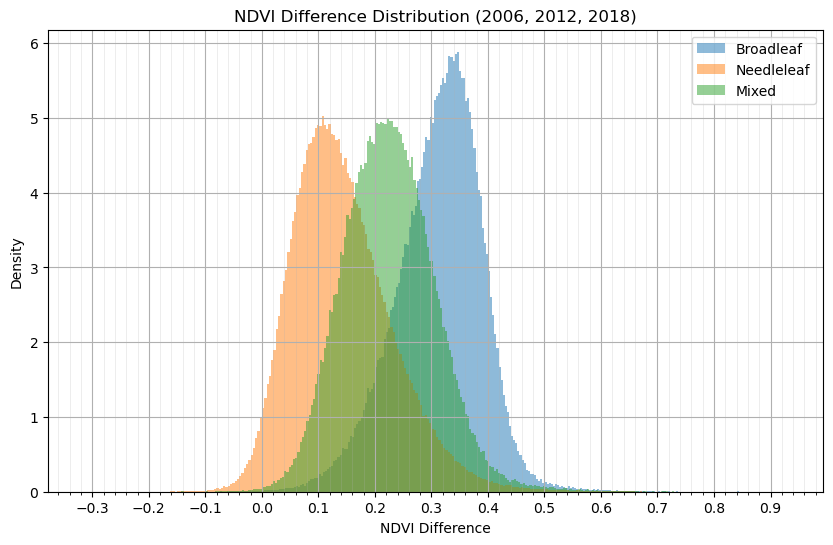

In [1]:
### NDVI Seasonal Difference Histogram - 2006, 2012, 2018

def load_ndvi_values(folder, years, value_col=1):
    files = glob.glob(folder + "/*.csv")

    files = [
        f for f in files
        if any(str(year) in f for year in years)
    ]

    values = []

    for f in files:
        df = pd.read_csv(f)
        vals = df.iloc[:, value_col].dropna()
        values.append(vals.values)

    return np.concatenate(values)

year = [2006, 2012, 2018]

laub_vals  = load_ndvi_values(r"PATH", year)
nadel_vals = load_ndvi_values(r"PATH", year)
misch_vals = load_ndvi_values(r"PATH", year)

print(len(laub_vals), len(nadel_vals), len(misch_vals))



plt.figure(figsize=(10,6))

from matplotlib.ticker import MultipleLocator

ax = plt.gca()

# Grid
ax.xaxis.set_minor_locator(MultipleLocator(0.02))

ax.xaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(which="major", axis="x", linewidth=0.8)

ax.grid(which="minor", axis="x", linewidth=0.4, alpha=0.4)

# Density
plt.hist(laub_vals, bins=300, density=True, alpha=0.5, label="Broadleaf")
plt.hist(nadel_vals, bins=300, density=True, alpha=0.5, label="Needleleaf")
plt.hist(misch_vals, bins=300, density=True, alpha=0.5, label="Mixed")

plt.xlabel("NDVI Difference")
plt.ylabel("Density")
plt.title("NDVI Difference Distribution (2006, 2012, 2018)")
plt.legend()
plt.grid(True)
plt.show()


162319 511639 209481


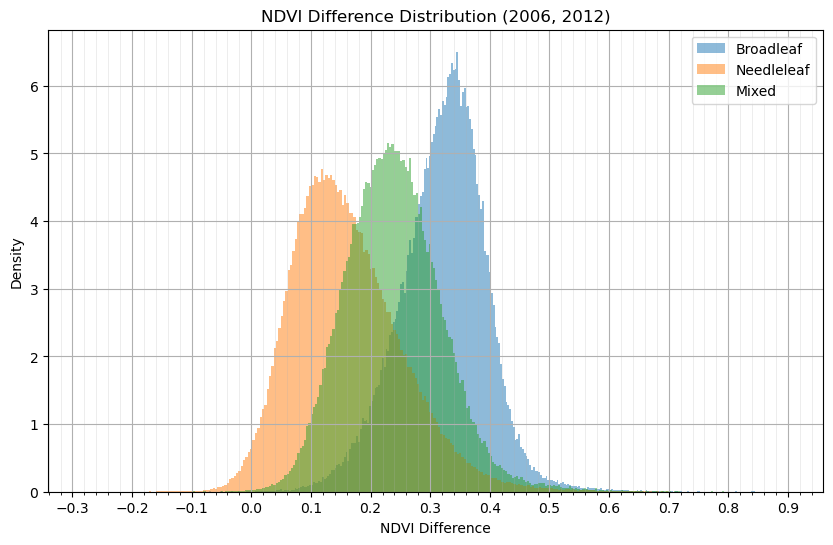

In [17]:
### NDVI Seasonal Difference Histogram - 2006, 2012


def load_ndvi_values(folder, years, value_col=1):
    files = glob.glob(folder + "/*.csv")

    files = [
        f for f in files
        if any(str(year) in f for year in years)
    ]

    values = []

    for f in files:
        df = pd.read_csv(f)
        vals = df.iloc[:, value_col].dropna()
        values.append(vals.values)

    return np.concatenate(values)

year = [2006, 2012]

laub_vals  = load_ndvi_values(r"PATH", year)
nadel_vals = load_ndvi_values(r"PATH", year)
misch_vals = load_ndvi_values(r"PATH", year)

print(len(laub_vals), len(nadel_vals), len(misch_vals))



plt.figure(figsize=(10,6))

from matplotlib.ticker import MultipleLocator

ax = plt.gca()

# Grid
ax.xaxis.set_minor_locator(MultipleLocator(0.02))

ax.xaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(which="major", axis="x", linewidth=0.8)

ax.grid(which="minor", axis="x", linewidth=0.4, alpha=0.4)

# Density
plt.hist(laub_vals, bins=300, density=True, alpha=0.5, label="Broadleaf")
plt.hist(nadel_vals, bins=300, density=True, alpha=0.5, label="Needleleaf")
plt.hist(misch_vals, bins=300, density=True, alpha=0.5, label="Mixed")

plt.xlabel("NDVI Difference")
plt.ylabel("Density")
plt.title("NDVI Difference Distribution (2006, 2012)")
plt.legend()
plt.grid(True)

plt.show()

161398 515898 211831


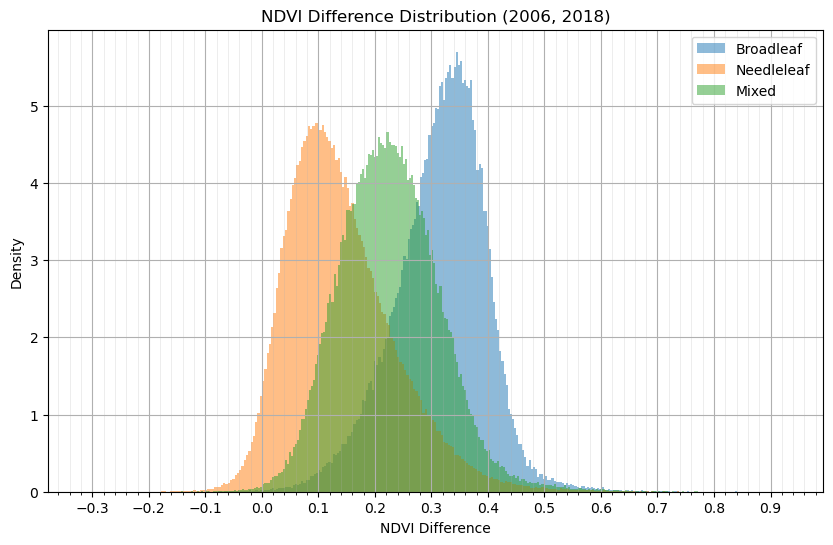

In [18]:
### NDVI Seasonal Difference Histogram - 2006, 2018


def load_ndvi_values(folder, years, value_col=1):
    files = glob.glob(folder + "/*.csv")

    files = [
        f for f in files
        if any(str(year) in f for year in years)
    ]

    values = []

    for f in files:
        df = pd.read_csv(f)
        vals = df.iloc[:, value_col].dropna()
        values.append(vals.values)

    return np.concatenate(values)

year = [2006, 2018]

laub_vals  = load_ndvi_values(r"PATH", year)
nadel_vals = load_ndvi_values(r"PATH", year)
misch_vals = load_ndvi_values(r"PATH", year)

print(len(laub_vals), len(nadel_vals), len(misch_vals))


plt.figure(figsize=(10,6))

from matplotlib.ticker import MultipleLocator

ax = plt.gca()

# Grid
ax.xaxis.set_minor_locator(MultipleLocator(0.02))

ax.xaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(which="major", axis="x", linewidth=0.8)

ax.grid(which="minor", axis="x", linewidth=0.4, alpha=0.4)

# Density
plt.hist(laub_vals, bins=300, density=True, alpha=0.5, label="Broadleaf")
plt.hist(nadel_vals, bins=300, density=True, alpha=0.5, label="Needleleaf")
plt.hist(misch_vals, bins=300, density=True, alpha=0.5, label="Mixed")


plt.xlabel("NDVI Difference")
plt.ylabel("Density")
plt.title("NDVI Difference Distribution (2006, 2018)")
plt.legend()
plt.grid(True)

plt.show()


224307 732115 299104


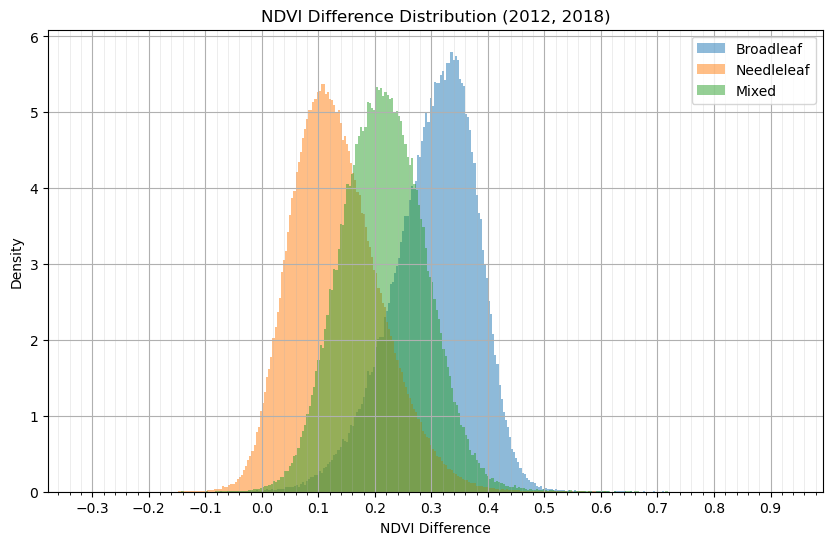

In [19]:
### NDVI Seasonal Difference Histogram - 2012, 2018


def load_ndvi_values(folder, years, value_col=1):
    files = glob.glob(folder + "/*.csv")

    files = [
        f for f in files
        if any(str(year) in f for year in years)
    ]

    values = []

    for f in files:
        df = pd.read_csv(f)
        vals = df.iloc[:, value_col].dropna()
        values.append(vals.values)

    return np.concatenate(values)

year = [2001, 2012, 2018]

laub_vals  = load_ndvi_values(r"PATH", year)
nadel_vals = load_ndvi_values(r"PATH", year)
misch_vals = load_ndvi_values(r"PATH", year)

print(len(laub_vals), len(nadel_vals), len(misch_vals))


plt.figure(figsize=(10,6))

from matplotlib.ticker import MultipleLocator

ax = plt.gca()

# Grid
ax.xaxis.set_minor_locator(MultipleLocator(0.02))

ax.xaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(which="major", axis="x", linewidth=0.8)

ax.grid(which="minor", axis="x", linewidth=0.4, alpha=0.4)

# Density
plt.hist(laub_vals, bins=300, density=True, alpha=0.5, label="Broadleaf")
plt.hist(nadel_vals, bins=300, density=True, alpha=0.5, label="Needleleaf")
plt.hist(misch_vals, bins=300, density=True, alpha=0.5, label="Mixed")

plt.xlabel("NDVI Difference")
plt.ylabel("Density")
plt.title("NDVI Difference Distribution (2012, 2018)")
plt.legend()
plt.grid(True)

plt.show()

111693 368187 150727


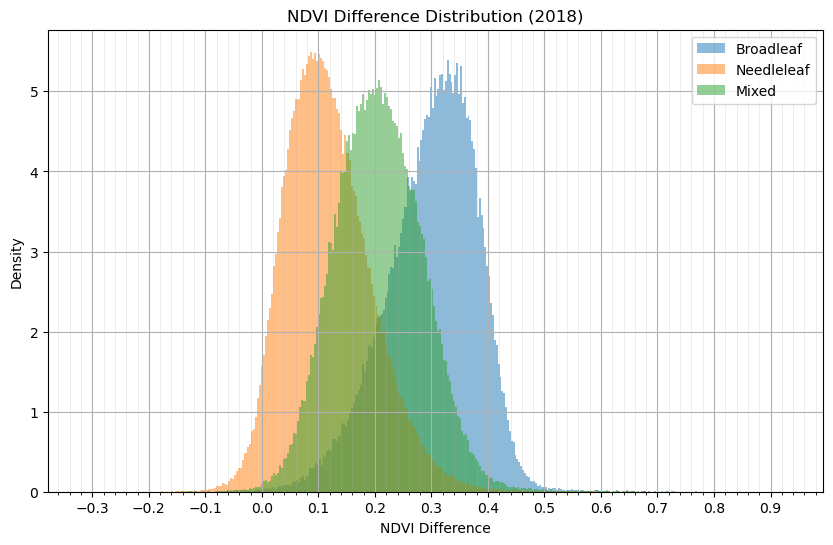

In [20]:
### NDVI Seasonal Difference Histogram - 2018


def load_ndvi_values(folder, years, value_col=1):
    files = glob.glob(folder + "/*.csv")

    files = [
        f for f in files
        if any(str(year) in f for year in years)
    ]

    values = []

    for f in files:
        df = pd.read_csv(f)
        vals = df.iloc[:, value_col].dropna()
        values.append(vals.values)

    return np.concatenate(values)

year = [2018]

laub_vals  = load_ndvi_values(r"PATH", year)
nadel_vals = load_ndvi_values(r"PATH", year)
misch_vals = load_ndvi_values(r"PATH", year)

print(len(laub_vals), len(nadel_vals), len(misch_vals))


plt.figure(figsize=(10,6))

from matplotlib.ticker import MultipleLocator

ax = plt.gca()

# Grid
ax.xaxis.set_minor_locator(MultipleLocator(0.02))

ax.xaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(which="major", axis="x", linewidth=0.8)

ax.grid(which="minor", axis="x", linewidth=0.4, alpha=0.4)

# Density
plt.hist(laub_vals, bins=300, density=True, alpha=0.5, label="Broadleaf")
plt.hist(nadel_vals, bins=300, density=True, alpha=0.5, label="Needleleaf")
plt.hist(misch_vals, bins=300, density=True, alpha=0.5, label="Mixed")

plt.xlabel("NDVI Difference")
plt.ylabel("Density")
plt.title("NDVI Difference Distribution (2018)")
plt.legend()
plt.grid(True)

plt.show()

112614 363928 148377


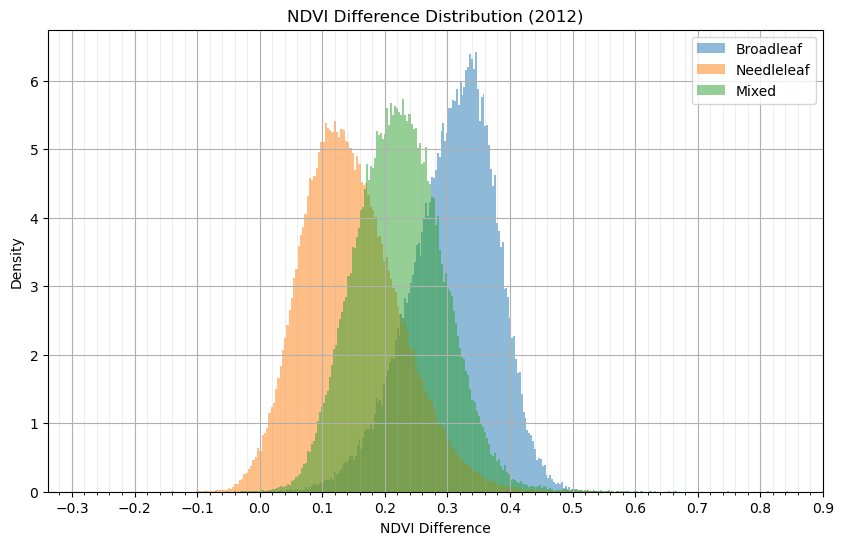

In [21]:
### NDVI Seasonal Difference Histogram - 2012


def load_ndvi_values(folder, years, value_col=1):
    files = glob.glob(folder + "/*.csv")

    files = [
        f for f in files
        if any(str(year) in f for year in years)
    ]

    values = []

    for f in files:
        df = pd.read_csv(f)
        vals = df.iloc[:, value_col].dropna()
        values.append(vals.values)

    return np.concatenate(values)

year = [2012]

laub_vals  = load_ndvi_values(r"PATH", year)
nadel_vals = load_ndvi_values(r"PATH", year)
misch_vals = load_ndvi_values(r"PATH", year)

print(len(laub_vals), len(nadel_vals), len(misch_vals))


plt.figure(figsize=(10,6))

from matplotlib.ticker import MultipleLocator

ax = plt.gca()

# Grid
ax.xaxis.set_minor_locator(MultipleLocator(0.02))

ax.xaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(which="major", axis="x", linewidth=0.8)

ax.grid(which="minor", axis="x", linewidth=0.4, alpha=0.4)

# Density
plt.hist(laub_vals, bins=300, density=True, alpha=0.5, label="Broadleaf")
plt.hist(nadel_vals, bins=300, density=True, alpha=0.5, label="Needleleaf")
plt.hist(misch_vals, bins=300, density=True, alpha=0.5, label="Mixed")

plt.xlabel("NDVI Difference")
plt.ylabel("Density")
plt.title("NDVI Difference Distribution (2012)")
plt.legend()
plt.grid(True)

plt.show()

49705 147711 61104


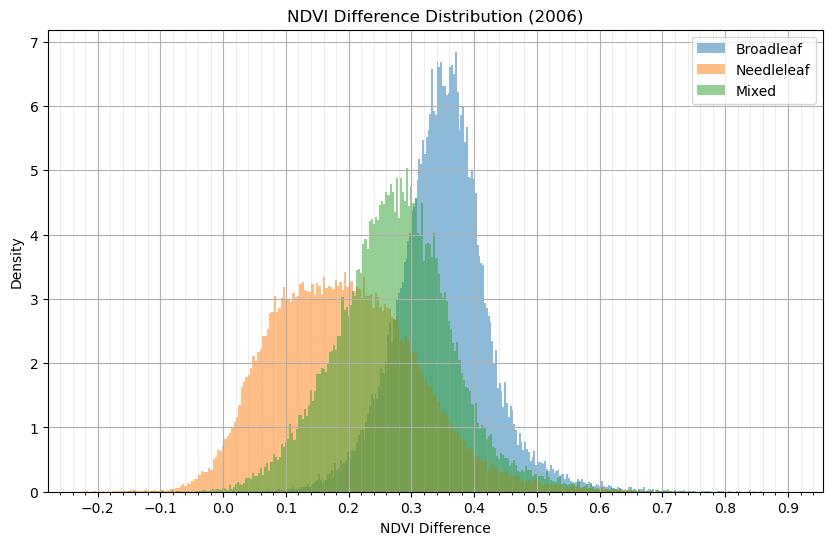

In [22]:
### NDVI Seasonal Difference Histogram - 2006


def load_ndvi_values(folder, years, value_col=1):
    files = glob.glob(folder + "/*.csv")

    files = [
        f for f in files
        if any(str(year) in f for year in years)
    ]

    values = []

    for f in files:
        df = pd.read_csv(f)
        vals = df.iloc[:, value_col].dropna()
        values.append(vals.values)

    return np.concatenate(values)

year = [2006]

laub_vals  = load_ndvi_values(r"PATH", year)
nadel_vals = load_ndvi_values(r"PATH", year)
misch_vals = load_ndvi_values(r"PATH", year)

print(len(laub_vals), len(nadel_vals), len(misch_vals))


plt.figure(figsize=(10,6))

from matplotlib.ticker import MultipleLocator

ax = plt.gca()

# Grid
ax.xaxis.set_minor_locator(MultipleLocator(0.02))

ax.xaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(which="major", axis="x", linewidth=0.8)

ax.grid(which="minor", axis="x", linewidth=0.4, alpha=0.4)

# Density
plt.hist(laub_vals, bins=300, density=True, alpha=0.5, label="Broadleaf")
plt.hist(nadel_vals, bins=300, density=True, alpha=0.5, label="Needleleaf")
plt.hist(misch_vals, bins=300, density=True, alpha=0.5, label="Mixed")

plt.xlabel("NDVI Difference")
plt.ylabel("Density")
plt.title("NDVI Difference Distribution (2006)")
plt.legend()
plt.grid(True)

plt.show()